## Project :Diabete Disease Predicition
###### Our project is a Diabetes Disease Prediction Model that leverages machine learning to forecast the risk of diabetes with precision and speed. By analyzing key health indicators, it empowers early detection.


# Steps Used:
## 1 Get Data                             
## 2 preprocess data
## 3 Train test split
## 4 Train the Model
## 5 Create Website

In [1]:
import pandas as pd
from sklearn import svm
from sklearn.metrics import accuracy_score
import seaborn as sns
from scipy.stats import uniform, randint
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 1 Get Data

In [2]:
diabete_df = pd.read_csv('diabetes.csv')
diabete_df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [3]:
diabete_df.shape

(768, 9)

# 2 Preprocess Data

In [4]:
diabete_df.info() #summary of dataframes and shows the dataTypes of each col.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
print(diabete_df.isnull().sum())  # gives how many missing values in each col.

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [6]:
diabete_df['Outcome'].value_counts() #1=person is diabetic and 0=non-diabetic

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
diabete_df.describe()#to analyze the summary statistics of our dataset.

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# 3 Separate Dependent & Independ Feature into x and y

In [8]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X = diabete_df[features]#Independent
y = diabete_df['Outcome']#Dependent

#  Standarization

In [9]:
#Standardization is essential when working with machine learning models,To ensure that all features contribute equally to the 
#model, we applied standardization using StandardScaler().
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
Standard_data = scaler.fit_transform(X)
X = Standard_data

In [10]:
print(X)

[[ 0.63994726  0.84832379  0.14964075 ...  0.20401277  0.46849198
   1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575 ... -0.68442195 -0.36506078
  -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 ... -1.10325546  0.60439732
  -0.10558415]
 ...
 [ 0.3429808   0.00330087  0.14964075 ... -0.73518964 -0.68519336
  -0.27575966]
 [-0.84488505  0.1597866  -0.47073225 ... -0.24020459 -0.37110101
   1.17073215]
 [-0.84488505 -0.8730192   0.04624525 ... -0.20212881 -0.47378505
  -0.87137393]]


# Train test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=25, random_state=1)

In [12]:
# Scale the features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4 Train Model

### MODEL TRINING WITH HYPERPARAMETER TUNING

In [13]:
models = {
    'SVM': {
        'model': svm.SVC(probability=True, random_state=42),
        'params': {
            'C': [0.1, 1.0, 10.0],
            'kernel': ['linear', 'rbf'],
            'max_iter': [1000]  # Added to prevent convergence warning
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 150],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5]  # Added to improve stability
        }
    },
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=2000),  # Increased max_iter
        'params': {
            'C': [0.1, 1.0, 10.0],
            'solver': ['lbfgs']  # Added solver specification
        }
    }
}

# Train with warning handling
import warnings
warnings.filterwarnings('ignore')  # Add this to suppress warnings

for name, model_info in models.items():
    print(f"\n=== {name} Model Cross-Validation Results ===")
    
    random_search = RandomizedSearchCV(
        model_info['model'],
        model_info['params'],
        n_iter=10,           
        cv=5,  
        scoring='accuracy',
        random_state=42    
    )
    
    random_search.fit(X_train_scaled, y_train)
    
    print(f"Best Cross-Validation Score: {random_search.best_score_:.3f}")
    print(f"Best Parameters: {random_search.best_params_}")


=== SVM Model Cross-Validation Results ===
Best Cross-Validation Score: 0.760
Best Parameters: {'max_iter': 1000, 'kernel': 'linear', 'C': 0.1}

=== Random Forest Model Cross-Validation Results ===
Best Cross-Validation Score: 0.766
Best Parameters: {'n_estimators': 150, 'min_samples_split': 5, 'max_depth': 10}

=== Logistic Regression Model Cross-Validation Results ===
Best Cross-Validation Score: 0.767
Best Parameters: {'solver': 'lbfgs', 'C': 1.0}



Step 3: Model Evaluation and Visualization


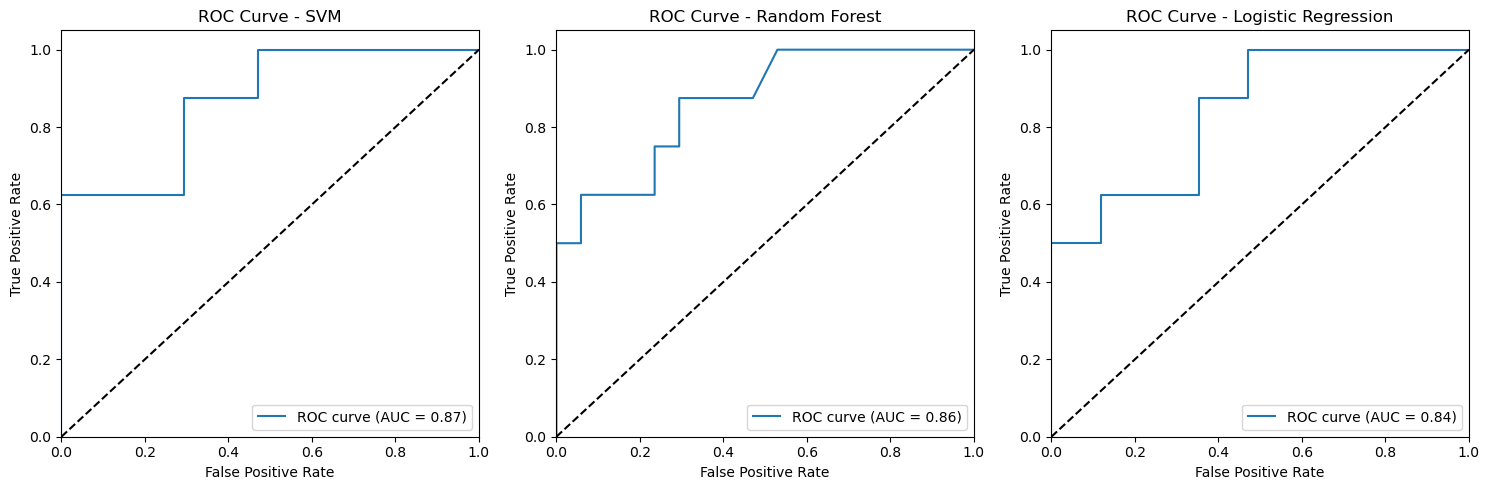


Results for SVM:
Accuracy: 88.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92        17
           1       1.00      0.62      0.77         8

    accuracy                           0.88        25
   macro avg       0.93      0.81      0.84        25
weighted avg       0.90      0.88      0.87        25



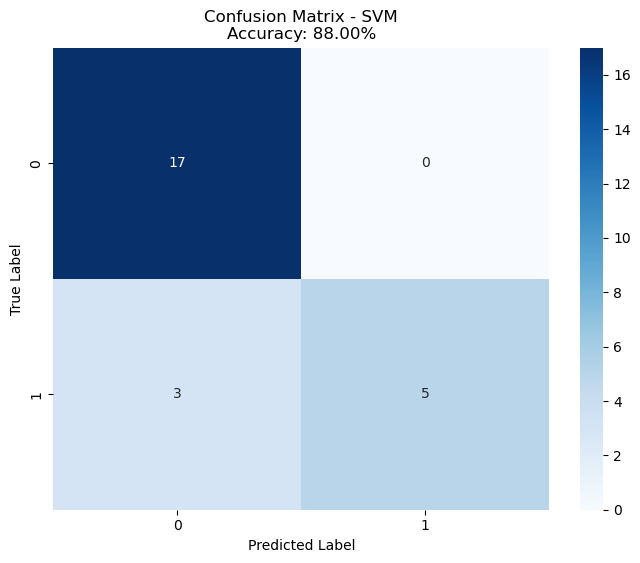


Results for Random Forest:
Accuracy: 84.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89        17
           1       0.83      0.62      0.71         8

    accuracy                           0.84        25
   macro avg       0.84      0.78      0.80        25
weighted avg       0.84      0.84      0.83        25



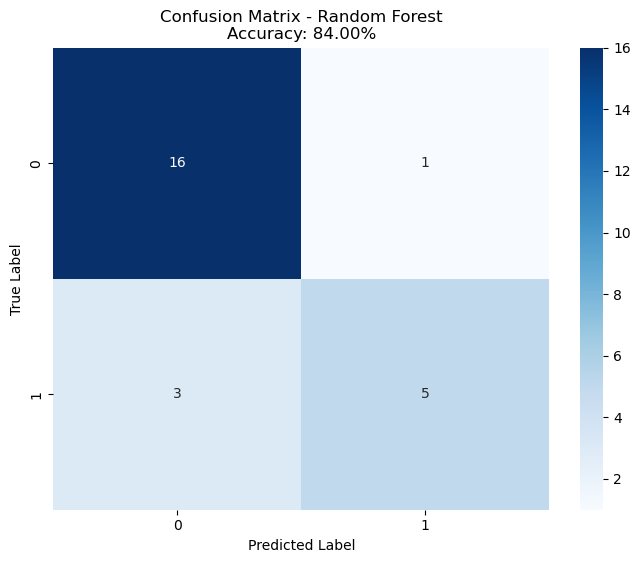


Results for Logistic Regression:
Accuracy: 84.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.81      1.00      0.89        17
           1       1.00      0.50      0.67         8

    accuracy                           0.84        25
   macro avg       0.90      0.75      0.78        25
weighted avg       0.87      0.84      0.82        25



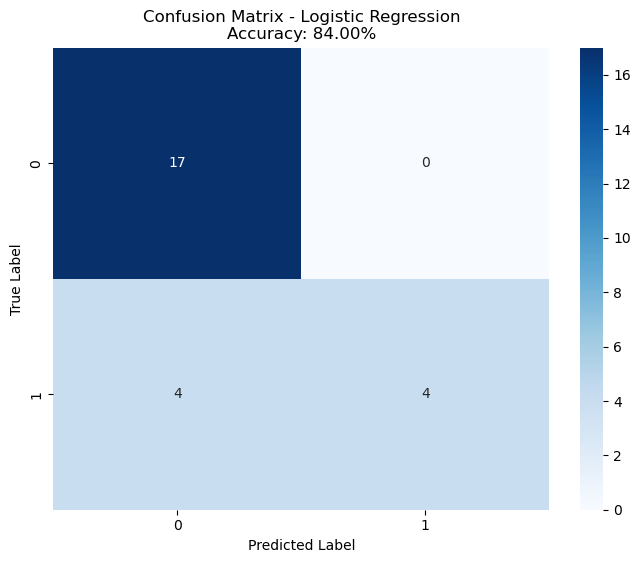

In [14]:
#Confusion Matrix : helps us analyze the performance of classification models by breaking down the predictions : TP, TN,FP, FN
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
# 1. First make sure we have all models stored properly
best_models = {}

# Define and train all models
models = {
    'SVM': svm.SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42)
}

# Train each model and store in best_models
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    best_models[name] = model

# 2. Now evaluate all models
print("\nStep 3: Model Evaluation and Visualization")

# Dictionary to store results
results = {}

# Plot ROC curves for all models
plt.figure(figsize=(15, 5))
for idx, (name, model) in enumerate(best_models.items()):
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Store results
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred)
    }
    
    # Plot ROC Curve
    plt.subplot(1, 3, idx+1)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {name}')
    plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

# Print results and plot confusion matrices for all models
for name, result in results.items():
    print(f"\nResults for {name}:")
    print(f"Accuracy: {result['accuracy']*100:.2f}%")
    print("\nClassification Report:")
    print(result['classification_report'])
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(result['confusion_matrix'], annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}\nAccuracy: {result["accuracy"]*100:.2f}%')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

#  Prediction System

In [ ]:
import pandas as pd
import numpy as np

def predict_diabetes(data):
    # Define feature names
    feature_names = ['Pregnancies', 'Glucose', 'BloodPressure','SkinThickness','Insulin', 
                    'BMI', 'DiabetesPedigreeFunction', 'Age']
    
    # Create a DataFrame with the input data
    input_data = pd.DataFrame([data], columns=feature_names)
    glucose = data[1]  # Get glucose value
    
    # Print detailed results
    print("\nDiabetes Prediction Results:")
    print("-" * 50)
    
    # Analyze glucose levels according to medical standards
    print("\nGlucose Level Analysis:")
    if glucose >= 200:
        print("⚠️ CRITICAL HIGH: Glucose level ≥200 mg/dL indicates definite diabetes")
        prediction = np.array([1])  # Definitely diabetic
        prediction_proba = np.array([0.05, 0.95])  # Very high confidence
    elif glucose >= 126:
        print("⚠️ HIGH: Glucose level ≥126 mg/dL indicates diabetes (if fasting)")
        # Use model but with higher weight on glucose
        scaled_input = scaler.transform(input_data)
        svm_model = best_models['SVM']
        prediction = svm_model.predict(scaled_input)
        prediction_proba = svm_model.predict_proba(scaled_input)[0]
        # Adjust probability if model disagrees with medical threshold
        if prediction[0] == 0:
            prediction_proba = np.array([0.3, 0.7])  # Bias towards diabetes
    elif glucose >= 100:
        print("⚠️ ELEVATED: Glucose level 100-125 mg/dL indicates pre-diabetes")
        scaled_input = scaler.transform(input_data)
        svm_model = best_models['SVM']
        prediction = svm_model.predict(scaled_input)
        prediction_proba = svm_model.predict_proba(scaled_input)[0]
    elif glucose >= 70:
        print("✅ NORMAL: Glucose level 70-99 mg/dL is in normal range")
        scaled_input = scaler.transform(input_data)
        svm_model = best_models['SVM']
        prediction = svm_model.predict(scaled_input)
        prediction_proba = svm_model.predict_proba(scaled_input)[0]
    else:
        print("⚠️ LOW: Glucose level below 70 mg/dL is unusually low (hypoglycemia)")
        scaled_input = scaler.transform(input_data)
        svm_model = best_models['SVM']
        prediction = svm_model.predict(scaled_input)
        prediction_proba = svm_model.predict_proba(scaled_input)[0]
    
    print("\nPrediction Result:")
    if prediction[0] == 1:
        print('⚠️ Person has diabetes')
        if glucose >= 200:
            print('Recommendation: Immediate medical consultation required')
        elif glucose >= 126:
            print('Recommendation: Medical consultation advised')
        else:
            print('Recommendation: Further medical testing advised')
    else:
        print('✅ Person likely does not have diabetes')
        if glucose >= 100:
            print('Note: Pre-diabetic range - lifestyle changes recommended')
    
    print(f"\nPrediction Confidence:")
    print(f"No Diabetes: {prediction_proba[0]:.2%}")
    print(f"Has Diabetes: {prediction_proba[1]:.2%}")
    


# Test cases with different glucose levels
print("Testing with Normal Glucose Level:")
sample_data1 = [8, 177, 64, 0, 0, 23.3, 0.672, 32]
predict_diabetes(sample_data1)



In [ ]:
import matplotlib.pyplot as plt


models = ['Logistic Regression', 'Random Forest', 'SVM']
accuracy = [0.84, 0.84, 0.88]

plt.figure(figsize=(8,6))
plt.plot(models, accuracy, marker='o', linestyle='-', color='blue', label='Accuracy')
plt.xlabel('Machine Learning Models')
plt.ylabel('Accuracy')
plt.title('Comparison of Accuracy Using Different ML Models')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
diabete_df.head(5)

# 5 Created Website